In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import warnings
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
warnings.filterwarnings('ignore')

In [ ]:
plt.rcParams['figure.figsize'] = (10,8)
plt.rcParams['figure.dpi'] = 100 
plt.rcParams['font.size'] = 14 

In [2]:
df = pd.read_csv('SampleData\SampleData\HomePrices.csv')

In [ ]:
x = df[["Area","Bedrooms","Age"]]
y = df["Price"]
x, y= np.array(x), np.array(y)
x = sm.add_constant(x)

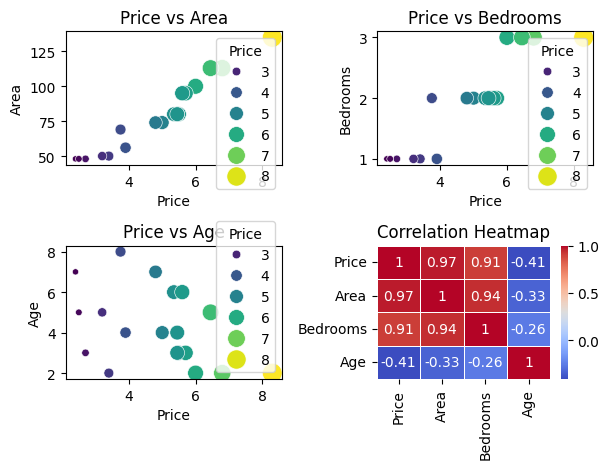

In [10]:
plt.subplot(2,2,1)
sns.scatterplot(data=df, x='Price', y='Area', hue = 'Price', palette='viridis', size='Price', sizes=(20, 200))
plt.title('Price vs Area')
plt.xlabel('Price') 
plt.ylabel('Area')

plt.subplot(2,2,2)
sns.scatterplot(data=df, x='Price', y='Bedrooms', hue = 'Price', palette='viridis', size='Price', sizes=(20, 200))
plt.title('Price vs Bedrooms')
plt.xlabel('Price')
plt.ylabel('Bedrooms')

plt.subplot(2,2,3)
sns.scatterplot(data=df, x='Price', y='Age', hue = 'Price', palette='viridis', size='Price', sizes=(20, 200))
plt.title('Price vs Age')
plt.xlabel('Price')
plt.ylabel('Age')

plt.subplot(2,2,4)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [13]:
vif_data = pd.DataFrame()
x_ = pd.DataFrame(x, columns=['const', 'Area', 'Bedrooms', 'Age'])
vif_data['feature'] = x_.columns
vif_data['VIF'] = [variance_inflation_factor(x_, i) for i in range(x_.shape[1])]
print(vif_data)

    feature        VIF
0     const  26.604500
1      Area   9.440766
2  Bedrooms   8.991972
3       Age   1.160055


In [14]:
model = sm.OLS(y, x)
results = model.fit()

In [15]:
R_sq = results.rsquared
params = results.params
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     87.69
Date:                Fri, 15 May 2026   Prob (F-statistic):           9.77e-10
Time:                        15:30:22   Log-Likelihood:                -7.4917
No. Observations:                  19   AIC:                             22.98
Df Residuals:                      15   BIC:                             26.76
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6474      0.478      1.354      0.1

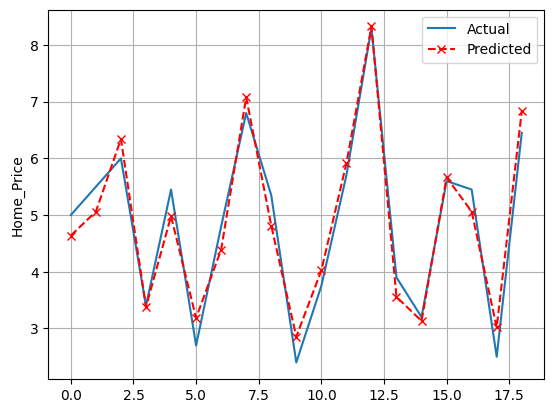

In [16]:
predicted_values = results.predict(x)
plt.plot(df["Price"], label="Actual")
plt.plot(predicted_values, label="Predicted",color='red',marker='x',linestyle='--')
plt.ylabel("Home_Price")
plt.legend()
plt.grid(True)
plt.show()